##Generating report based on database.json and prediction.json

In [31]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import find_peaks, welch

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
from collections import defaultdict
import warnings

warnings.filterwarnings('ignore')

In [32]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

Open file

In [33]:
FILENAME = 'Datasets/dataset.json'

In [34]:
with open(FILENAME) as f:
    data = json.load(f)

In [35]:
data_Dict = {}
stats_Dict = {}

In [36]:
if data:
    print(f"Loaded {len(data)} traces successfully.")
    print(f"Websites found: {set(d['website'] for d in data)}")

Loaded 6000 traces successfully.
Websites found: {'https://google.com', 'https://cse.buet.ac.bd/moodle/', 'https://prothomalo.com'}


In [37]:
for d in data:
    website = d['website']
    if website not in data_Dict:
        data_Dict[website] = []
    data_Dict[website].append(np.array(d['trace_data']))

In [38]:
print(f"\nData summary:")
for website, traces in data_Dict.items():
    print(f"{website}: {len(traces)} traces, avg length: {np.mean([len(t) for t in traces]):.1f}")


Data summary:
https://cse.buet.ac.bd/moodle/: 2000 traces, avg length: 1000.0
https://google.com: 2000 traces, avg length: 1000.0
https://prothomalo.com: 2000 traces, avg length: 1000.0


In [39]:
def calculate_comprehensive_stats(traces_np):
    """Calculate comprehensive statistics for trace data"""
    stats_dict = {
        "mean": np.mean(traces_np, axis=0),
        "median": np.median(traces_np, axis=0),
        "std_dev": np.std(traces_np, axis=0),
        "min": np.min(traces_np, axis=0),
        "max": np.max(traces_np, axis=0),
        "percentile_25": np.percentile(traces_np, 25, axis=0),
        "percentile_75": np.percentile(traces_np, 75, axis=0),
        "skewness": stats.skew(traces_np, axis=0),
        "kurtosis": stats.kurtosis(traces_np, axis=0),
        "variance": np.var(traces_np, axis=0),
        "range": np.max(traces_np, axis=0) - np.min(traces_np, axis=0),
    }
    
    # Calculate IQR
    stats_dict["iqr"] = stats_dict["percentile_75"] - stats_dict["percentile_25"]
    
    # Calculate Signal-to-Noise Ratio (SNR)
    stats_dict["snr"] = stats_dict["mean"] / (stats_dict["std_dev"] + 1e-10)
    
    return stats_dict

In [40]:
for website, traces in data_Dict.items():
    traces_np = np.array(traces)
    if len(traces_np.shape) == 2:
        stats_Dict[website] = calculate_comprehensive_stats(traces_np)
    else:
        print(f"Skipping {website} due to irregular trace lengths.")

In [41]:
def plot_trace_overview(data_dict, max_traces=5):
    """Plot sample traces for each website"""
    fig, axes = plt.subplots(len(data_dict), 1, figsize=(15, 3*len(data_dict)))
    if len(data_dict) == 1:
        axes = [axes]
    
    for idx, (website, traces) in enumerate(data_dict.items()):
        ax = axes[idx]
        for i, trace in enumerate(traces[:max_traces]):
            ax.plot(trace, alpha=0.7, label=f'Trace {i+1}' if i < 3 else None)
        ax.set_title(f'{website} - Sample Traces')
        ax.set_xlabel('Time/Sample')
        ax.set_ylabel('Amplitude')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [42]:
def plot_statistical_distributions(stats_dict):
    """Plot distributions of key statistics across websites"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    metrics = ['mean', 'std_dev', 'skewness', 'kurtosis', 'snr', 'iqr']
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        
        for website in stats_dict:
            values = stats_dict[website][metric]
            ax.hist(values, alpha=0.6, label=website, bins=30)
        
        ax.set_title(f'Distribution of {metric.replace("_", " ").title()}')
        ax.set_xlabel(metric.replace("_", " ").title())
        ax.set_ylabel('Frequency')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [43]:
def plot_correlation_heatmap(stats_dict):
    """Plot correlation heatmap between different statistics"""
    # Prepare data for correlation analysis
    correlation_data = []
    
    for website in stats_dict:
        website_stats = stats_dict[website]
        row = []
        for metric in ['mean', 'std_dev', 'skewness', 'kurtosis', 'snr', 'variance']:
            row.extend(website_stats[metric])
        correlation_data.append(row)
    
    # Calculate correlation matrix
    corr_matrix = np.corrcoef(np.array(correlation_data))
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
                xticklabels=[f'{website}' for website in stats_dict.keys()],
                yticklabels=[f'{website}' for website in stats_dict.keys()])
    plt.title('Cross-Website Correlation Matrix')
    plt.tight_layout()
    plt.show()

In [44]:
def plot_pca_analysis(data_dict):
    """Perform PCA analysis on trace data"""
    all_traces = []
    labels = []
    
    for website, traces in data_dict.items():
        for trace in traces:
            all_traces.append(trace)
            labels.append(website)
    
    # Standardize the data
    scaler = StandardScaler()
    traces_scaled = scaler.fit_transform(all_traces)
    
    # Perform PCA
    pca = PCA(n_components=2)
    traces_pca = pca.fit_transform(traces_scaled)
    
    # Plot PCA results
    plt.figure(figsize=(12, 8))
    
    unique_labels = list(set(labels))
    colors = plt.cm.Set3(np.linspace(0, 1, len(unique_labels)))
    
    for i, website in enumerate(unique_labels):
        mask = [label == website for label in labels]
        plt.scatter(traces_pca[mask, 0], traces_pca[mask, 1], 
                   c=[colors[i]], label=website, alpha=0.7, s=50)
    
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    plt.title('PCA Analysis of Side Channel Traces')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return pca.explained_variance_ratio_

In [45]:
def plot_snr_analysis(stats_dict):
    """Analyze Signal-to-Noise Ratio across websites"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # SNR over time/samples
    for website in stats_dict:
        snr_values = stats_dict[website]['snr']
        ax1.plot(snr_values, label=website, alpha=0.8)
    
    ax1.set_title('Signal-to-Noise Ratio Over Time')
    ax1.set_xlabel('Sample Index')
    ax1.set_ylabel('SNR')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Average SNR comparison
    avg_snr = {website: np.mean(stats_dict[website]['snr']) for website in stats_dict}
    websites = list(avg_snr.keys())
    snr_values = list(avg_snr.values())
    
    bars = ax2.bar(websites, snr_values, alpha=0.8)
    ax2.set_title('Average SNR by Website')
    ax2.set_ylabel('Average SNR')
    ax2.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, value in zip(bars, snr_values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{value:.2f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

In [46]:
def plot_peak_analysis(data_dict):
    """Analyze peaks in trace data"""
    fig, axes = plt.subplots(len(data_dict), 1, figsize=(15, 4*len(data_dict)))
    if len(data_dict) == 1:
        axes = [axes]
    
    peak_stats = {}
    
    for idx, (website, traces) in enumerate(data_dict.items()):
        ax = axes[idx]
        
        # Calculate average trace
        avg_trace = np.mean(traces, axis=0)
        
        # Find peaks
        peaks, properties = find_peaks(avg_trace, height=np.std(avg_trace), distance=10)
        
        # Plot average trace and peaks
        ax.plot(avg_trace, label='Average Trace', linewidth=2)
        ax.plot(peaks, avg_trace[peaks], 'ro', markersize=8, label=f'Peaks ({len(peaks)})')
        
        ax.set_title(f'{website} - Peak Analysis')
        ax.set_xlabel('Sample Index')
        ax.set_ylabel('Amplitude')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Store peak statistics
        peak_stats[website] = {
            'num_peaks': len(peaks),
            'peak_positions': peaks.tolist(),
            'peak_heights': avg_trace[peaks].tolist(),
            'avg_peak_height': np.mean(avg_trace[peaks]) if len(peaks) > 0 else 0
        }
    
    plt.tight_layout()
    plt.show()
    
    return peak_stats

In [47]:
def plot_frequency_analysis(data_dict):
    """Perform frequency domain analysis"""
    fig, axes = plt.subplots(len(data_dict), 1, figsize=(15, 4*len(data_dict)))
    if len(data_dict) == 1:
        axes = [axes]
    
    for idx, (website, traces) in enumerate(data_dict.items()):
        ax = axes[idx]
        
        # Calculate average trace
        avg_trace = np.mean(traces, axis=0)
        
        # Perform FFT
        fft_result = np.fft.fft(avg_trace)
        freqs = np.fft.fftfreq(len(avg_trace))
        
        # Plot power spectrum (only positive frequencies)
        positive_freqs = freqs[:len(freqs)//2]
        power_spectrum = np.abs(fft_result[:len(fft_result)//2])**2
        
        ax.semilogy(positive_freqs, power_spectrum)
        ax.set_title(f'{website} - Frequency Analysis')
        ax.set_xlabel('Frequency (normalized)')
        ax.set_ylabel('Power (log scale)')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [48]:
def clustering_analysis(data_dict):
    """Perform clustering analysis on traces"""
    all_traces = []
    labels = []
    
    for website, traces in data_dict.items():
        for trace in traces:
            all_traces.append(trace)
            labels.append(website)
    
    # Standardize the data
    scaler = StandardScaler()
    traces_scaled = scaler.fit_transform(all_traces)
    
    # Perform K-means clustering
    n_clusters = len(data_dict)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(traces_scaled)
    
    # Perform PCA for visualization
    pca = PCA(n_components=2)
    traces_pca = pca.fit_transform(traces_scaled)
    
    # Plot clustering results
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # True labels
    unique_labels = list(set(labels))
    colors = plt.cm.Set3(np.linspace(0, 1, len(unique_labels)))
    
    for i, website in enumerate(unique_labels):
        mask = [label == website for label in labels]
        ax1.scatter(traces_pca[mask, 0], traces_pca[mask, 1], 
                   c=[colors[i]], label=website, alpha=0.7, s=50)
    
    ax1.set_title('True Website Labels')
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Cluster labels
    scatter = ax2.scatter(traces_pca[:, 0], traces_pca[:, 1], 
                         c=cluster_labels, cmap='viridis', alpha=0.7, s=50)
    ax2.set_title('K-means Clustering Results')
    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
    ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
    plt.colorbar(scatter, ax=ax2)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate clustering accuracy
    from sklearn.metrics import adjusted_rand_score
    label_to_num = {label: i for i, label in enumerate(unique_labels)}
    true_labels_num = [label_to_num[label] for label in labels]
    
    ari_score = adjusted_rand_score(true_labels_num, cluster_labels)
    print(f"Clustering Adjusted Rand Index: {ari_score:.3f}")
    
    return ari_score

1. Trace Overview:


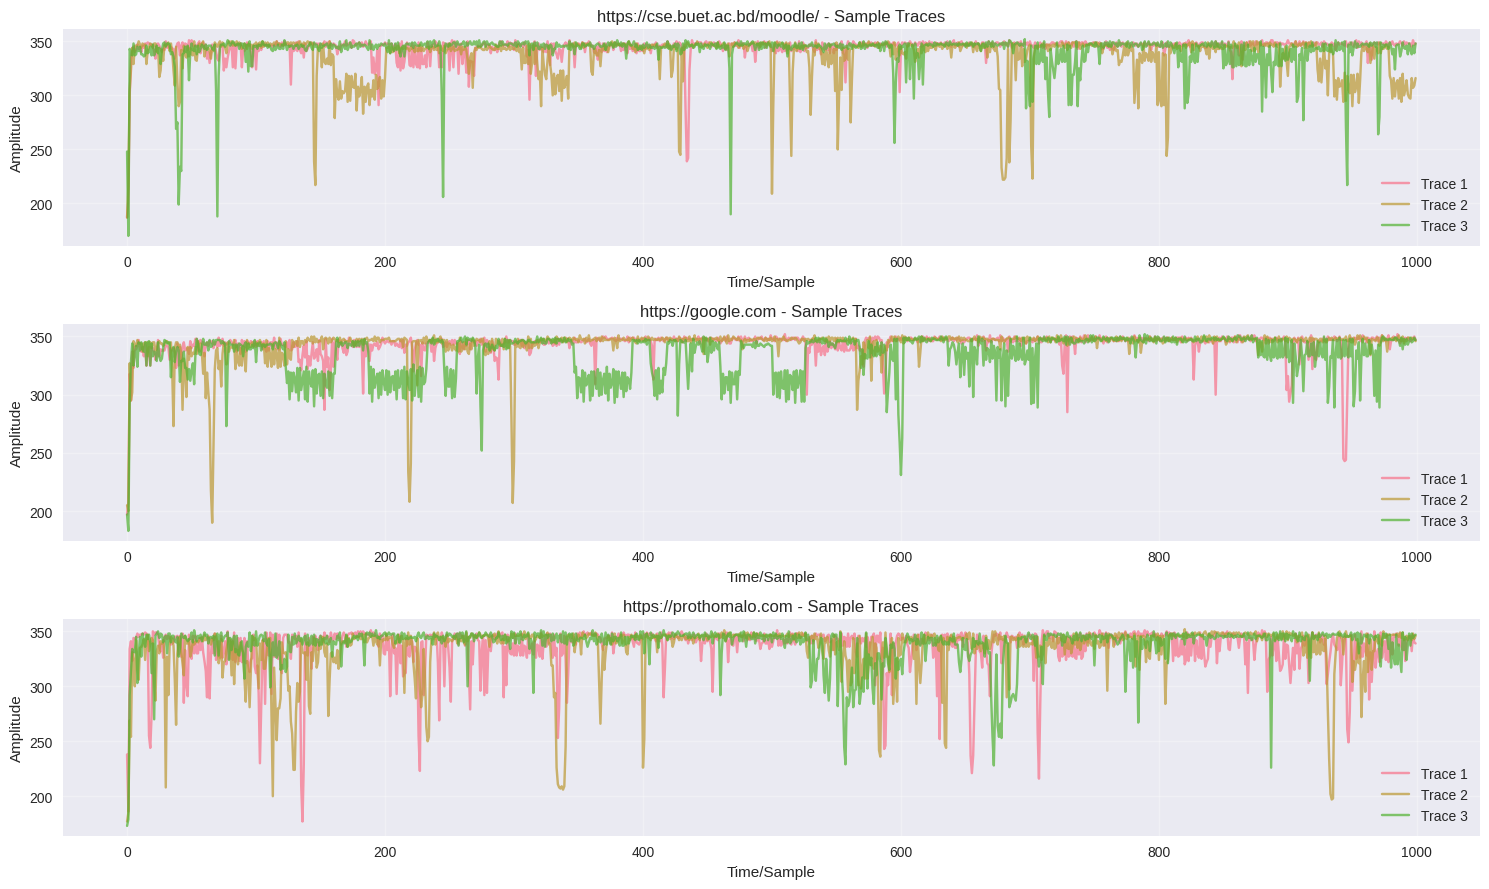

In [49]:
print("1. Trace Overview:")
plot_trace_overview(data_Dict, max_traces=3)


2. Statistical Distributions:


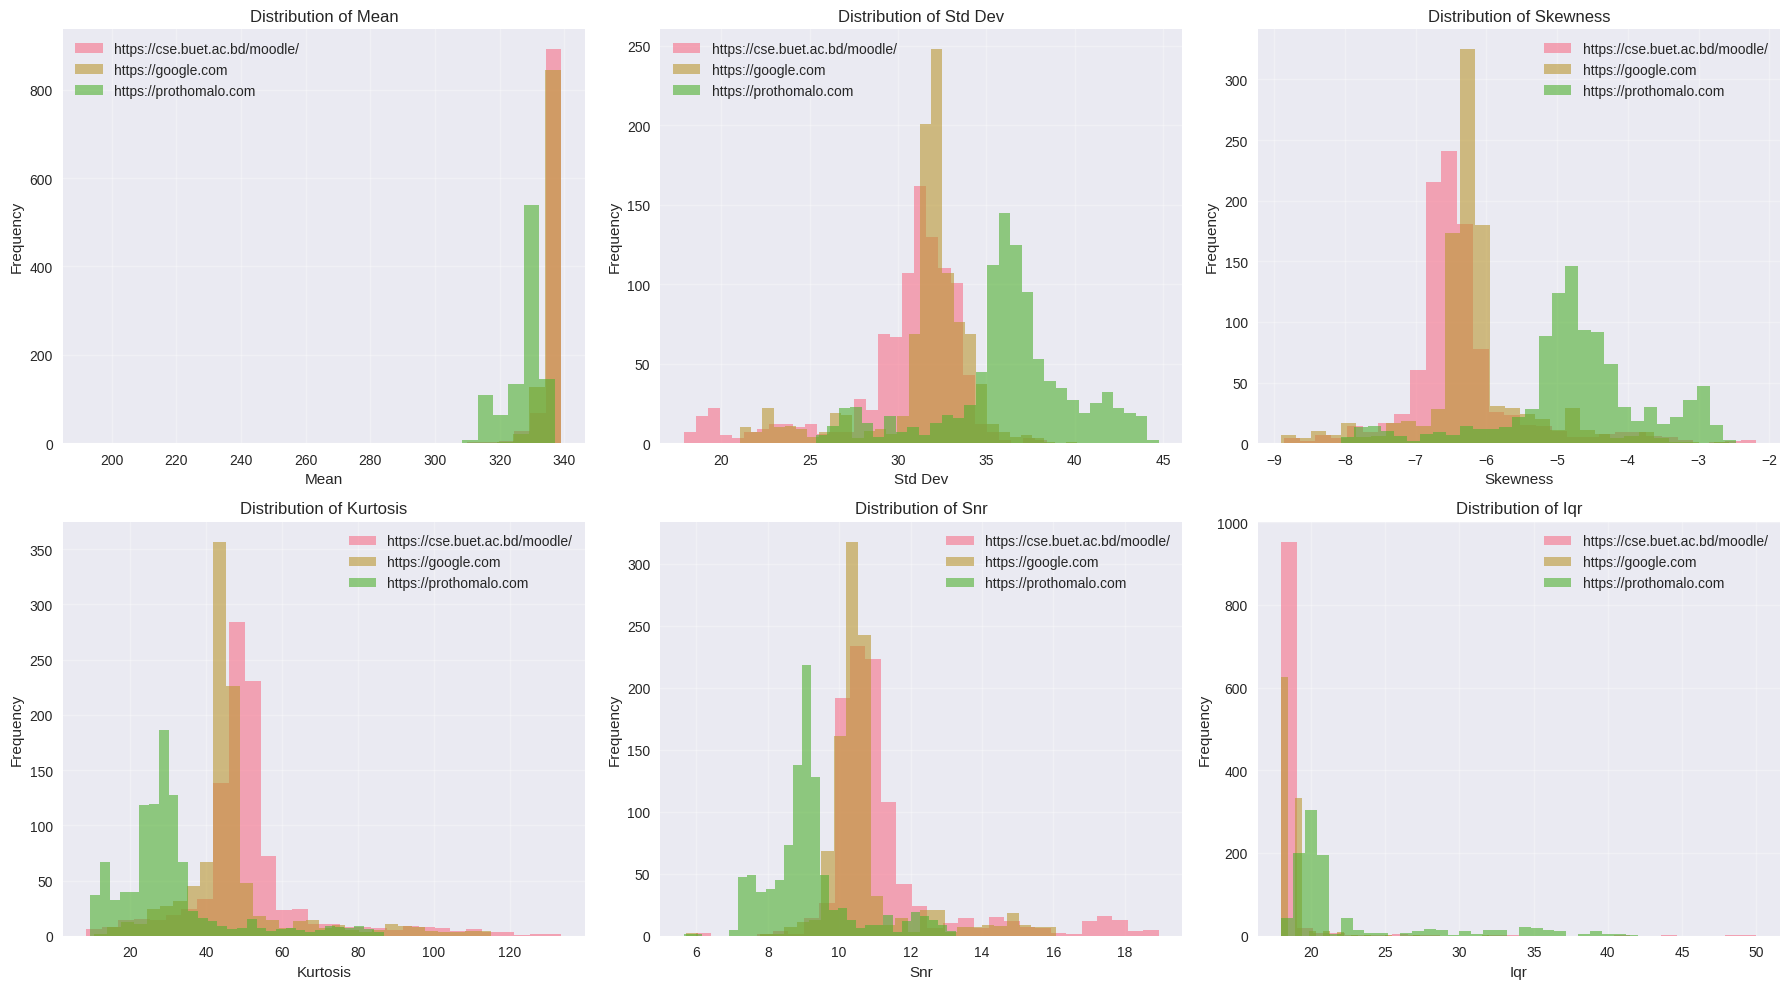

In [50]:
print("\n2. Statistical Distributions:")
plot_statistical_distributions(stats_Dict)


3. Signal-to-Noise Ratio Analysis:


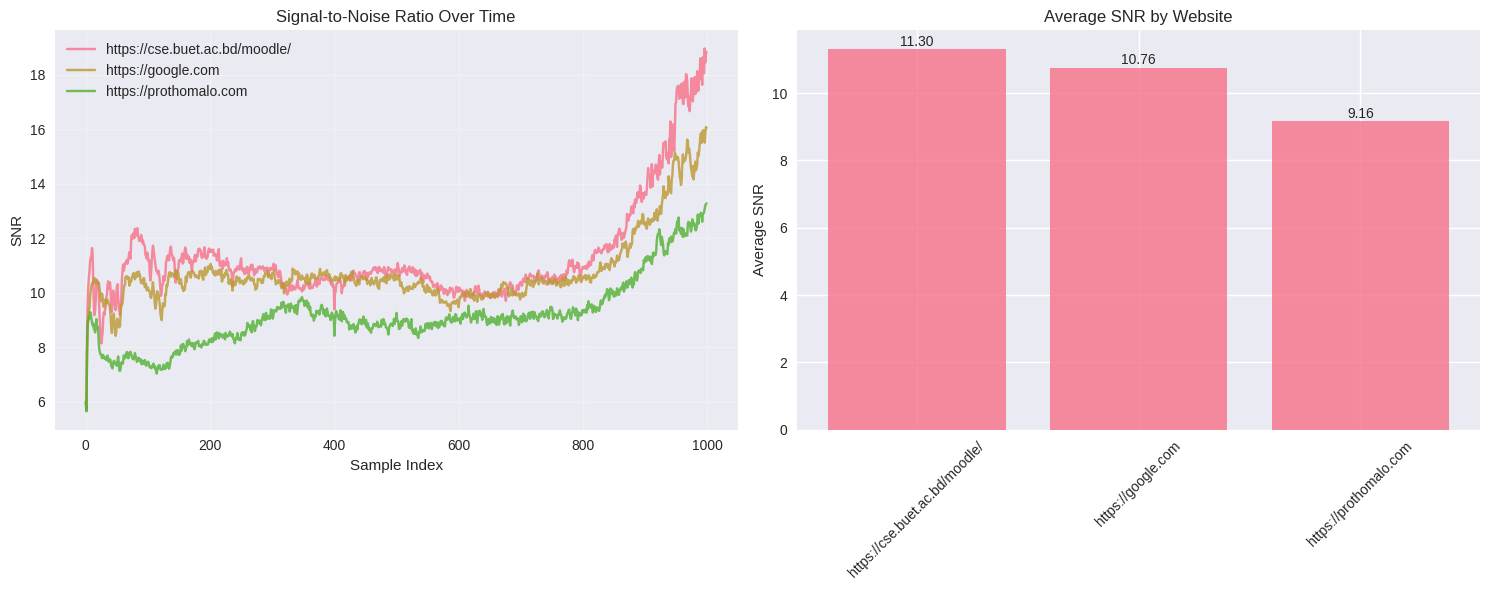

In [51]:
print("\n3. Signal-to-Noise Ratio Analysis:")
plot_snr_analysis(stats_Dict)


4. Principal Component Analysis:


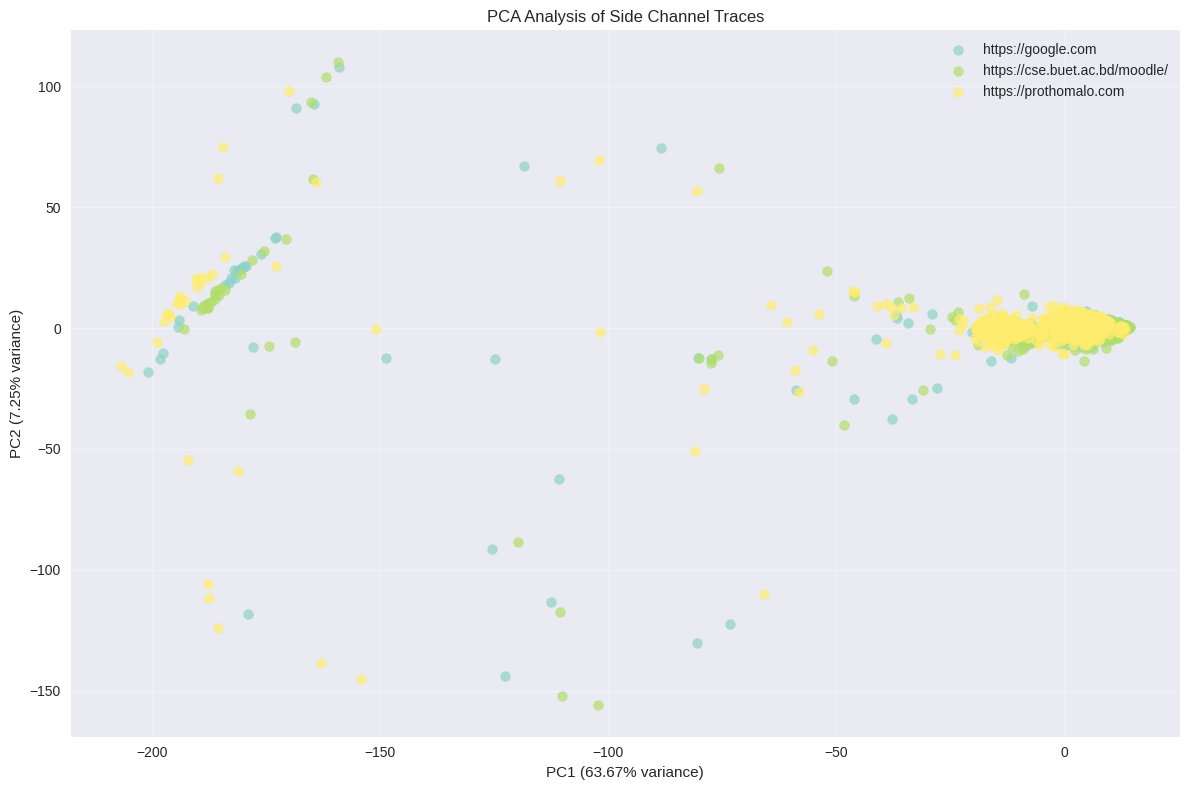

First two PCs explain 70.93% of variance


In [52]:
print("\n4. Principal Component Analysis:")
explained_variance = plot_pca_analysis(data_Dict)
print(f"First two PCs explain {sum(explained_variance):.2%} of variance")



5. Peak Analysis:


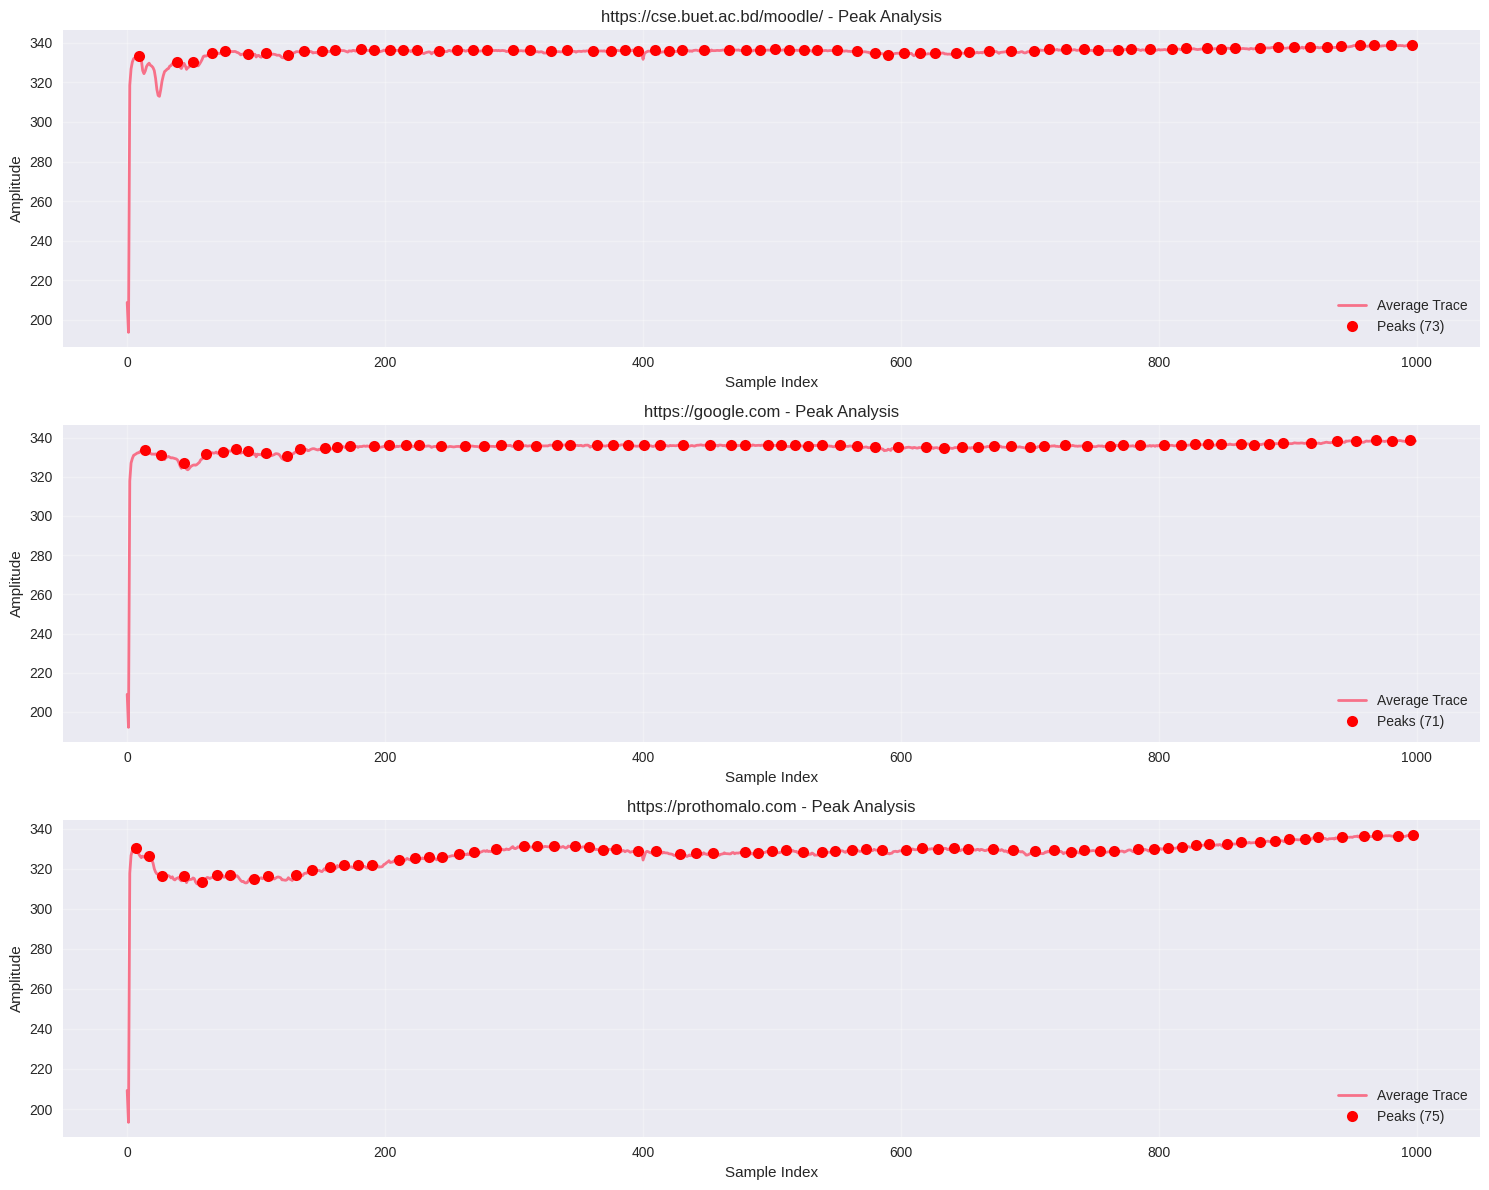

https://cse.buet.ac.bd/moodle/: 73 peaks, avg height: 336.181
https://google.com: 71 peaks, avg height: 335.599
https://prothomalo.com: 75 peaks, avg height: 328.281


In [53]:
print("\n5. Peak Analysis:")
peak_stats = plot_peak_analysis(data_Dict)
for website, stats in peak_stats.items():
    print(f"{website}: {stats['num_peaks']} peaks, avg height: {stats['avg_peak_height']:.3f}")



6. Frequency Domain Analysis:


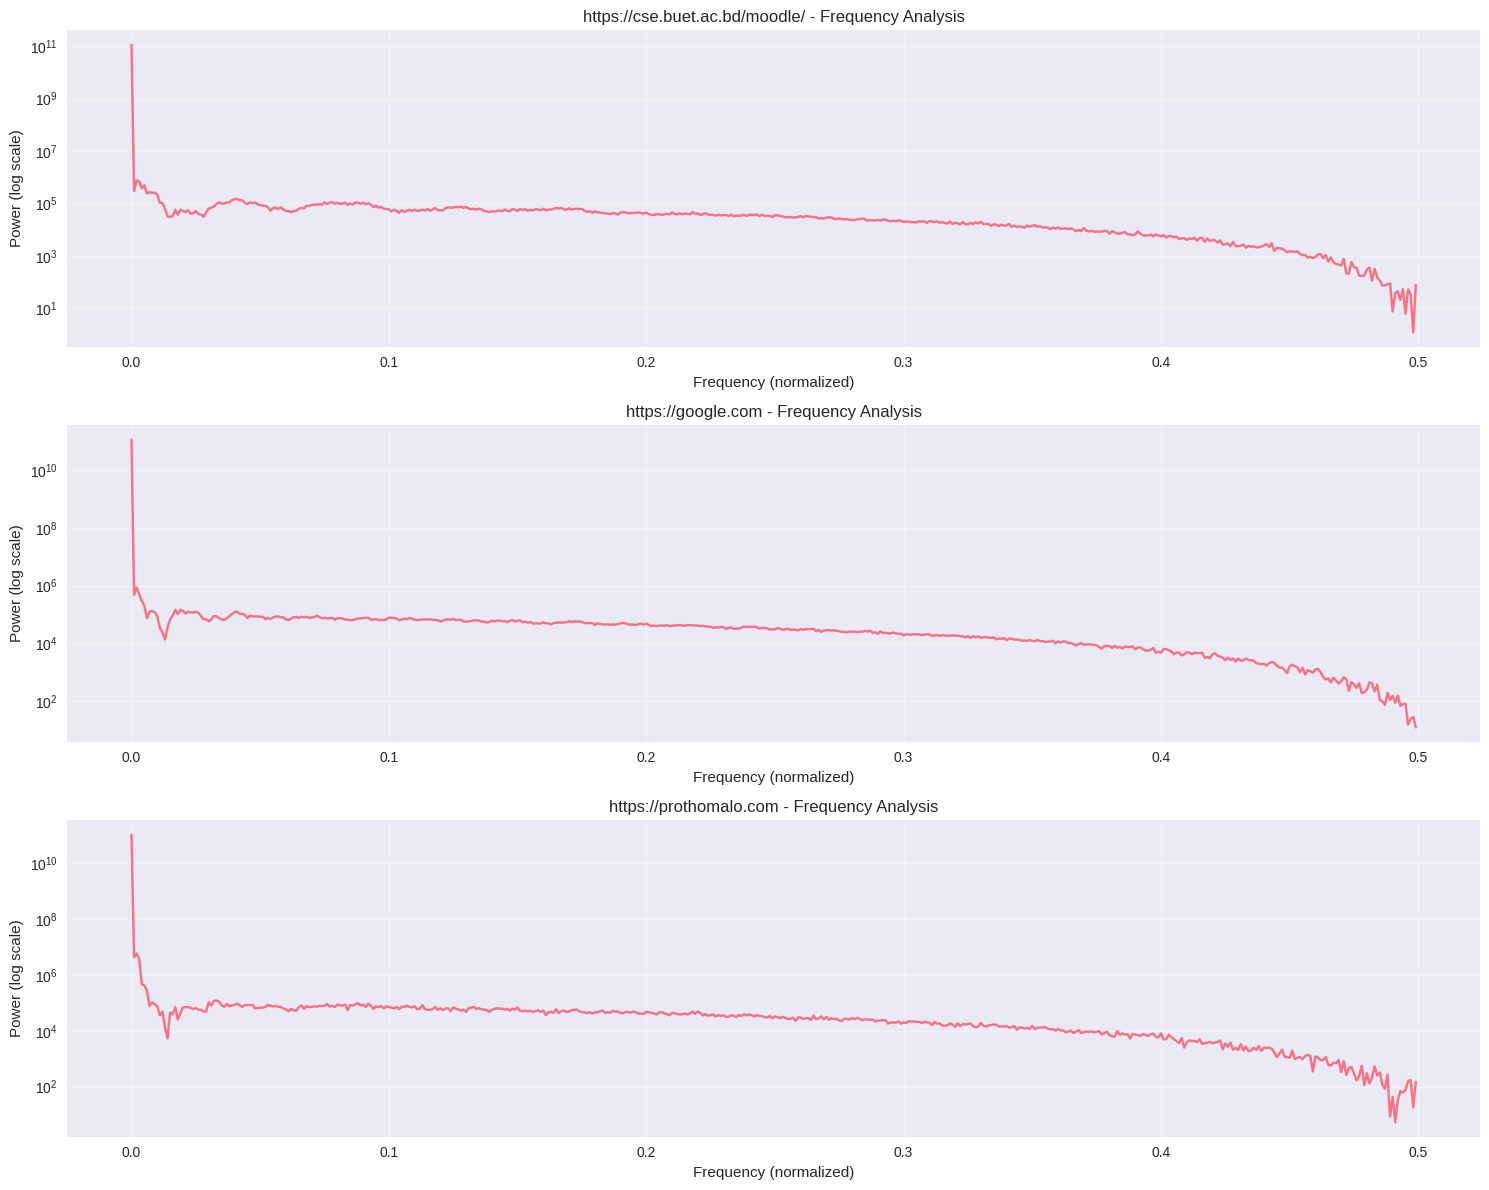

In [54]:
print("\n6. Frequency Domain Analysis:")
plot_frequency_analysis(data_Dict)


7. Clustering Analysis:


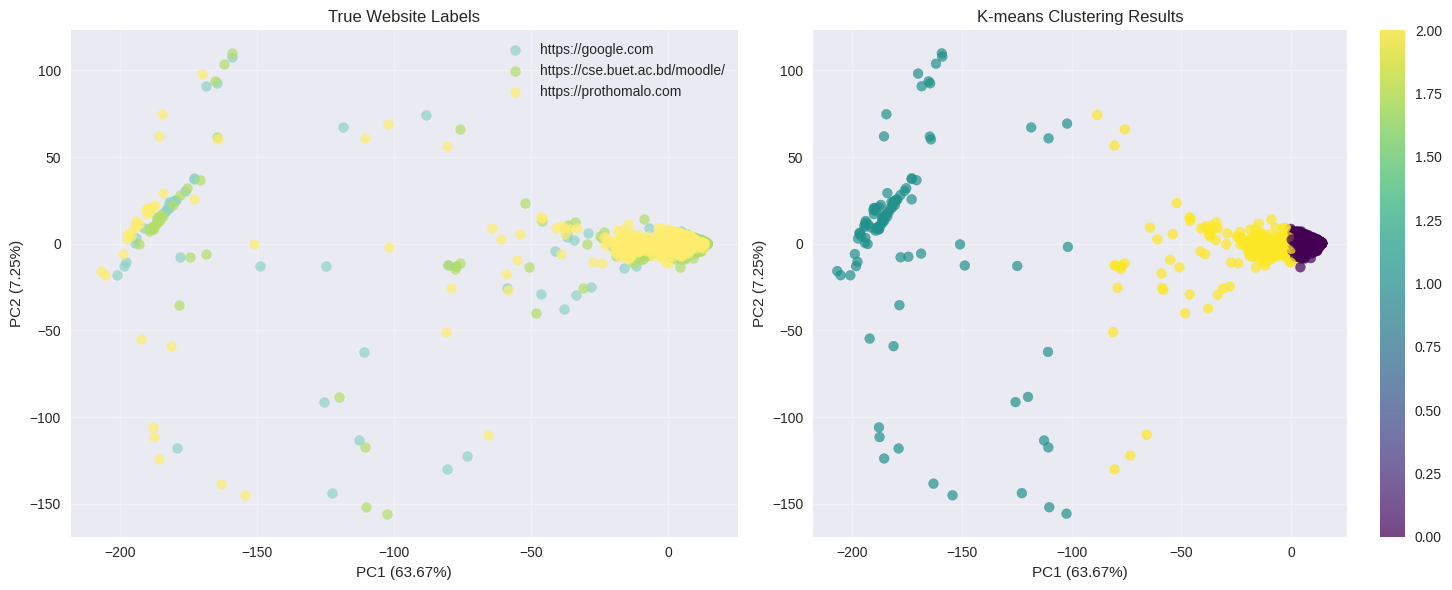

Clustering Adjusted Rand Index: 0.001


In [55]:
print("\n7. Clustering Analysis:")
ari_score = clustering_analysis(data_Dict)

In [56]:
print("\n8. Summary Statistics:")
summary_df = pd.DataFrame()


8. Summary Statistics:


In [57]:
for website in stats_Dict:
    row = {
        'Website': website,
        'Num_Traces': len(data_Dict[website]),
        'Avg_Trace_Length': np.mean([len(t) for t in data_Dict[website]]),
        'Avg_SNR': np.mean(stats_Dict[website]['snr']),
        'Avg_Std_Dev': np.mean(stats_Dict[website]['std_dev']),
        'Avg_Skewness': np.mean(stats_Dict[website]['skewness']),
        'Avg_Kurtosis': np.mean(stats_Dict[website]['kurtosis']),
        'Num_Peaks': peak_stats[website]['num_peaks'] if website in peak_stats else 0
    }
    summary_df = pd.concat([summary_df, pd.DataFrame([row])], ignore_index=True)

In [58]:
print(summary_df.to_string(index=False))

                       Website  Num_Traces  Avg_Trace_Length   Avg_SNR  Avg_Std_Dev  Avg_Skewness  Avg_Kurtosis  Num_Peaks
https://cse.buet.ac.bd/moodle/        2000            1000.0 11.304067    30.256445     -6.376010     51.415060         73
            https://google.com        2000            1000.0 10.761894    31.476027     -6.188542     46.887373         71
        https://prothomalo.com        2000            1000.0  9.159854    36.239673     -4.731068     30.243998         75


In [59]:
def assess_leakage(stats_dict):
    """Assess potential information leakage"""
    print("\n9. Leakage Assessment:")
    
    # Calculate distinguishing features
    metrics = ['mean', 'std_dev', 'snr', 'skewness', 'kurtosis']
    
    for metric in metrics:
        values_by_website = {}
        for website in stats_dict:
            values_by_website[website] = np.mean(stats_dict[website][metric])
        
        # Calculate coefficient of variation
        all_values = list(values_by_website.values())
        cv = np.std(all_values) / np.mean(all_values) if np.mean(all_values) != 0 else 0
        
        print(f"{metric.upper()} - Coefficient of Variation: {cv:.3f}")
        if cv > 0.1:
            print(f"  → HIGH potential for leakage via {metric}")
        elif cv > 0.05:
            print(f"  → MODERATE potential for leakage via {metric}")
        else:
            print(f"  → LOW potential for leakage via {metric}")

assess_leakage(stats_Dict)


9. Leakage Assessment:
MEAN - Coefficient of Variation: 0.011
  → LOW potential for leakage via mean
STD_DEV - Coefficient of Variation: 0.079
  → MODERATE potential for leakage via std_dev
SNR - Coefficient of Variation: 0.087
  → MODERATE potential for leakage via snr
SKEWNESS - Coefficient of Variation: -0.128
  → LOW potential for leakage via skewness
KURTOSIS - Coefficient of Variation: 0.212
  → HIGH potential for leakage via kurtosis


In [60]:
print("\n" + "="*50)
print("ANALYSIS COMPLETE")
print("="*50)


ANALYSIS COMPLETE
